# Watermarking for Summarization

**Laizhen Li**  
Shenzhen Institutes of Advanced Technology, Chinese Academy of Sciences

This notebook presents my implementation and analysis of watermarking for text summarization. I first evaluate the original soft and hard watermark conditions on BART-large-CNN and CNN/DailyMail, then examine why stronger watermark bias can reduce summary quality. Finally, I evaluate **Stratified Watermarking**, which preserves probability mass within high-probability and complementary regions while retaining the same detector.

The notebook accompanies `report.pdf`. The saved-results path reproduces the reported tables and figures without requiring GPU inference. A separate optional section can generate new outputs.

**Reading this notebook:** saved outputs were generated locally on September 24, 2026 from the archived experiment records, with dependency installation skipped and new GPU generation disabled. They are not hosted Colab results. Run the cells to regenerate the analysis; GPU experiments are optional at the end.


In [1]:
# @title Download the pinned experiment package
from pathlib import Path
import os, sys, json, subprocess, zipfile, io, urllib.request

# The public repository and commit are fixed for reproducibility.
REPOSITORY = "Lilaizhen/stratified-watermarking-summarization"
REVISION = "559fa0faa69c43cf8698a669e15be1957d9fee10"
local_ready = Path("src/workflow.py").exists() and Path("archived/records.json").exists()
if Path(".download_complete").exists():
    local_ready = local_ready and Path(".download_complete").read_text().strip() == REVISION
if not local_ready:
    destination = Path("watermark_" + REVISION).resolve()
    if not (destination / ".download_complete").exists():
        with urllib.request.urlopen(f"https://codeload.github.com/{REPOSITORY}/zip/{REVISION}", timeout=120) as response:
            payload = response.read()
        with zipfile.ZipFile(io.BytesIO(payload)) as archive:
            for member in archive.infolist():
                relative = Path(*Path(member.filename).parts[1:])
                target = (destination / relative).resolve()
                if not target.is_relative_to(destination): raise ValueError("Unsafe archive path")
                if member.is_dir(): target.mkdir(parents=True, exist_ok=True)
                else:
                    target.parent.mkdir(parents=True, exist_ok=True); target.write_bytes(archive.read(member))
        (destination / ".download_complete").write_text(REVISION)
    os.chdir(destination)
sys.path.insert(0, str(Path("src").resolve()))
print("Code revision:", REVISION)

Code revision: 559fa0faa69c43cf8698a669e15be1957d9fee10


### Setup
Run once in a fresh runtime. Installation may require a runtime restart; rerun from the top afterward. Saved results need no GPU. Detailed troubleshooting is in the repository README.

In [2]:
# @title Install dependencies and verify packaged inputs
INSTALL = True
if INSTALL:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
import hashlib
for name, digest in json.loads(Path("MANIFEST.json").read_text()).items():
    content = Path(name).read_bytes()
    if name == "configs/focused/alignscore.json":
        value = json.loads(content)
        for key in ("checkpoint", "backbone_snapshot"): value.pop(key, None)
        content = (json.dumps(value, indent=2) + "\n").encode()
    if hashlib.sha256(content).hexdigest() != digest: raise ValueError(f"Changed input: {name}")
print("Environment ready; inputs verified.")

Environment ready; inputs verified.


## 1. Objective and experimental protocol

The research question is: **how does watermark bias affect detectability and summary quality, and can the quality cost be reduced at comparable detection rates?**

The protocol uses BART-large-CNN, CNN/DailyMail 3.0.0, temperature 0.8, full-vocabulary multinomial sampling (`top_k=0`, `top_p=1`), and bias after temperature scaling. The 200 calibration articles are disjoint from the 500 evaluation articles. The main bias grid is $\delta=0.5,1.0,\ldots,6.0,8,10,12$ at $\gamma=0.5$. All methods use the same evaluation articles.


In [3]:
base = json.loads(Path("configs/base.json").read_text())
splits = json.loads(Path("configs/splits.json").read_text())
assert len(splits["calibration"]) == 200 and len(splits["test"]) == 500
assert not {r["id"] for r in splits["calibration"]} & {r["id"] for r in splits["test"]}
print(f"Model: {base['model']}  | temperature: {base['temperature']}  | top-k: {base['top_k']}  | top-p: {base['top_p']}")
print(f"Calibration articles: {len(splits['calibration'])}  | evaluation articles: {len(splits['test'])}")

Model: facebook/bart-large-cnn  | temperature: 0.8  | top-k: 0  | top-p: 1.0
Calibration articles: 200  | evaluation articles: 500


## 2. Original watermark and evaluation

At each decoding step, a fixed key and the preceding token determine the green list $G_t$.

**Soft.** Green logits receive bias $\delta$ after temperature scaling; red tokens remain available. At a fixed prefix, the green-to-red probability odds are multiplied by $e^\delta$.

**Hard.** Red logits are set to $-\infty$, restricting sampling to green candidates. The forced initial BOS step is exempt; subsequent EOS tokens are subject to the mask when otherwise allowed.

**Detection.** For $T$ distinct eligible token pairs and $N_G$ green events,
$$z=\frac{N_G-gT}{\sqrt{Tg(1-g)}},\qquad g=\frac{\lfloor\gamma |V|\rfloor}{|V|}.$$
Repeated pairs count once and special-token transitions are excluded. The threshold is the ascending $\lceil(n+1)(1-0.01)\rceil$-th score of the independent calibration set, with the strict decision rule $z>\tau$. Evaluation negatives measure FPR and ROC-AUC; they do not determine the threshold. At $\gamma=0.5$, $\tau=2.672612$ and measured FPR is 0.6%.

**Quality.** ROUGE-1/2/L F1 measures reference overlap; GPT-2-medium corpus PPL $\exp(\sum\mathrm{NLL}/\sum\mathrm{tokens})$ is an unconditional fluency proxy; AlignScore-base `nli_sp` measures source consistency. PPL excludes BOS/EOS/padding targets. Higher ROUGE and AlignScore and lower PPL are preferred. ROUGE uses a 0–100 scale and AlignScore a 0–1 scale.


## 3. Original watermark: bias and green-list fraction

First, I vary the Soft bias at fixed $\gamma=0.5$. The following cells recompute metrics from archived per-summary evaluation records and draw the figures directly with Matplotlib. No saved image files are loaded; these cells do not rerun model generation or evaluation.


Reconstructed 66 configurations; independent thresholds, PPL and ROUGE verified.


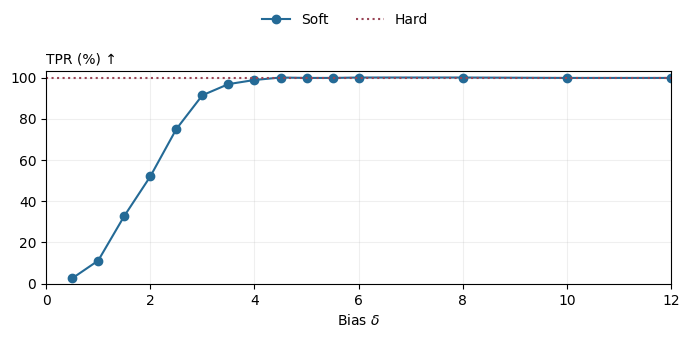

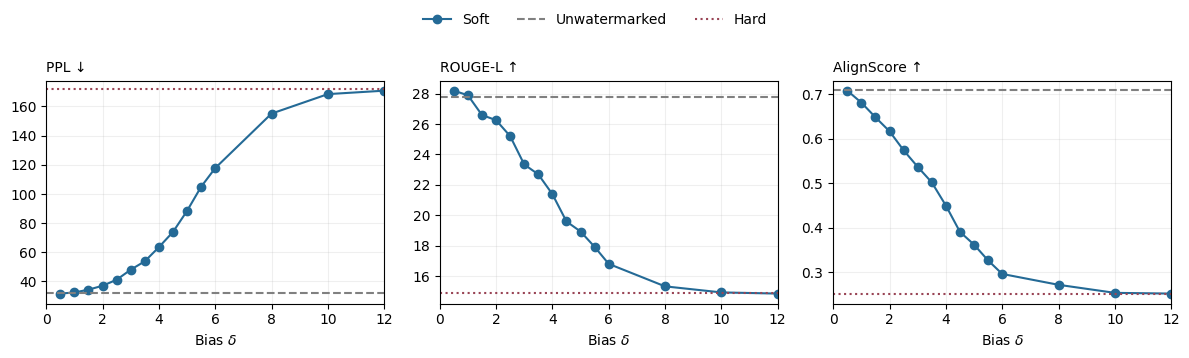

In [4]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
from plots import rebuild_metrics

# Recalculate metrics from per-summary records; this function draws no figures.
metrics, targets, gamma = rebuild_metrics()
soft = metrics[(metrics.method == "kgw") & metrics.gamma.eq(.5)].sort_values("delta")
nw = metrics.loc[metrics.name == "nw"].iloc[0]
hard = metrics.loc[metrics.name == "hard"].iloc[0]

# Detection versus bias. TPR is stored as a fraction, so multiply by 100.
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(soft.delta, 100 * soft.tpr, "o-", color="#246a96", label="Soft")
ax.axhline(100 * hard.tpr, color="#994455", linestyle=":", label="Hard")
ax.set(xlabel=r"Bias $\delta$", xlim=(0, 12), ylim=(0, 103))
ax.set_xticks(range(0, 13, 2))
ax.set_title("TPR (%) ↑", loc="left", fontsize=10)
ax.grid(alpha=.2)
fig.legend(*ax.get_legend_handles_labels(), loc="upper center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, .90))
plt.show()

# Quality versus bias, using the same Soft configurations.
quality_metrics = [("ppl", "PPL ↓"), ("rougeL_fmeasure", "ROUGE-L ↑"),
                   ("alignscore_nli_sp", "AlignScore ↑")]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (metric, label) in zip(axes, quality_metrics):
    ax.plot(soft.delta, soft[metric], "o-", color="#246a96", label="Soft")
    ax.axhline(nw[metric], color="gray", linestyle="--", label="Unwatermarked")
    ax.axhline(hard[metric], color="#994455", linestyle=":", label="Hard")
    ax.set(xlabel=r"Bias $\delta$", xlim=(0, 12))
    ax.set_xticks(range(0, 13, 2))
    ax.set_title(label, loc="left", fontsize=10)
    ax.grid(alpha=.2)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, .88))
plt.show()

**Observation.** As $\delta$ increases, TPR rises before saturating, while ROUGE-L and AlignScore generally decrease and PPL increases. Further increasing bias can therefore damage quality after detection saturates.

Next, I vary the green-list fraction at fixed $\delta=2.5$, calibrating a separate threshold for each $\gamma$.


In [5]:
# Format for reading; retain full-precision metrics for calculations.
gamma_table = gamma.sort_values("gamma")[["gamma", "threshold", "tpr", "fpr", "auc", "ppl", "rougeL_fmeasure", "alignscore_nli_sp"]].copy()
gamma_table[["tpr", "fpr"]] *= 100
gamma_table.columns = ["γ", "Threshold τ", "TPR (%) ↑", "FPR (%)", "ROC-AUC ↑", "PPL ↓", "ROUGE-L ↑", "AlignScore ↑"]
display(gamma_table.style.hide(axis="index").format({
    "γ": "{:.2f}", "Threshold τ": "{:.4f}", "TPR (%) ↑": "{:.1f}", "FPR (%)": "{:.1f}",
    "ROC-AUC ↑": "{:.3f}", "PPL ↓": "{:.2f}", "ROUGE-L ↑": "{:.2f}", "AlignScore ↑": "{:.2f}"}))

γ,Threshold τ,TPR (%) ↑,FPR (%),ROC-AUC ↑,PPL ↓,ROUGE-L ↑,AlignScore ↑
0.10,2.6475,56.6,0.4,0.938,39.05,25.50,0.63
0.25,2.5981,76.2,0.2,0.979,40.65,24.70,0.59
0.50,2.6726,75.0,0.6,0.981,41.16,25.20,0.57
0.75,2.2644,58.2,1.4,0.950,35.66,25.79,0.64
0.90,2.1519,18.6,0.4,0.873,33.51,26.71,0.67


**Observation.** TPR first increases and then decreases, with the highest observed rates at $\gamma=0.25$ and $0.5$. Larger fractions yield lower PPL and higher ROUGE-L and AlignScore than $\gamma=0.5$, but weaker detection.

## 4. Motivation: probability mass changes

To examine a possible source of quality degradation, I measure the probability assigned after watermarking to the **same token sets that originally covered at least 90%, 95%, or 98% of the unwatermarked probability**. These are teacher-forced, same-prefix diagnostics rather than new sampled summaries.

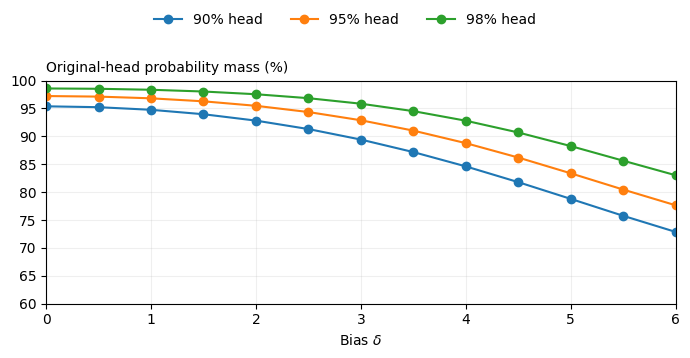

In [6]:
# This CSV contains position-weighted statistics from the 500-article diagnostic.
# Replot actual total probabilities, not ratios to the original head mass.
head = pd.read_csv("archived/head_mass.csv")
head = head[(head.group == "all") & head.method.isin(["NW", "W-soft"])].sort_values("delta")
assert head.articles.eq(500).all() and head.positions.eq(35795).all()

fig, ax = plt.subplots(figsize=(7, 3.6))
for threshold in (90, 95, 98):
    ax.plot(head.delta, 100 * head[f"head{threshold}_after_mean"], "o-",
            label=f"{threshold}% head")
ax.set(xlabel=r"Bias $\delta$", xlim=(0, 6), ylim=(60, 100))
ax.set_xticks(range(7))
ax.set_title("Original-head probability mass (%)", loc="left", fontsize=10)
ax.grid(alpha=.2)
fig.legend(*ax.get_legend_handles_labels(), loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, .88))
plt.show()

**Interpretation.** As bias increases, the original high-probability token sets receive less total probability and their complements receive more. This suggests that shifting probability toward tokens the model originally considered less likely may contribute to the quality decline. The diagnostic motivates a regional normalization constraint, but does not by itself prove causality for GPT-2 PPL or summary quality.

## 5. Stratified Watermarking and comparison

Motivated by the probability shift, I partition the temperature-scaled distribution $p$ into a minimal descending-probability head reaching $\rho$ and its complementary tail. The crossing token is included. Within each region $B$,
$$q(i)=P_B\frac{p(i)e^{\delta\mathbf{1}\{i\in G\}}}{\sum_{j\in B}p(j)e^{\delta\mathbf{1}\{j\in G\}}},\qquad P_B=\sum_{j\in B}p(j).$$
The transformation preserves each region's total probability at the current prefix, while individual token probabilities can change. No extra special-token protection is applied. The detector still reconstructs the same keyed colors and does not need the partition.

The readable reference implementation below is checked against the log-sum-exp implementation used for generation.


In [7]:
import torch
from headmass_processor import mass_preserving_tilt

# Readable reference implementation: normalize the green tilt inside each region.
def stratified_distribution(logits, green, rho=0.98, delta=4.0):
    p = logits.float().softmax(-1)  # logits are already temperature-scaled
    order = p.argsort(dim=-1, descending=True, stable=True)
    sorted_p = p.gather(-1, order)
    head_sorted = sorted_p.cumsum(-1) - sorted_p < rho
    head = torch.zeros_like(green).scatter(-1, order, head_sorted)
    q = torch.zeros_like(p)
    for region in (head, ~head):
        original_mass = (p * region).sum(-1, keepdim=True)
        tilted = p * region * torch.exp(delta * green.float())
        q += original_mass * tilted / tilted.sum(-1, keepdim=True).clamp_min(1e-30)
    return q

# The production implementation uses stable log-sum-exp corrections.
torch.manual_seed(17)
logits = torch.randn(3, 127)
green = torch.rand_like(logits) > 0.5
reference = stratified_distribution(logits, green)
production = mass_preserving_tilt(logits, green, [], .98, 4).softmax(-1)
torch.testing.assert_close(reference, production, atol=2e-6, rtol=2e-5)
print("Regional normalization matches the generation implementation.")

Regional normalization matches the generation implementation.


/home/llz/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Head-threshold sensitivity

I compare $\rho=0.90,0.95,0.98$ at temperature 0.8 and $\gamma=0.5$, using the same fifteen-bias grid and calibrated detector.

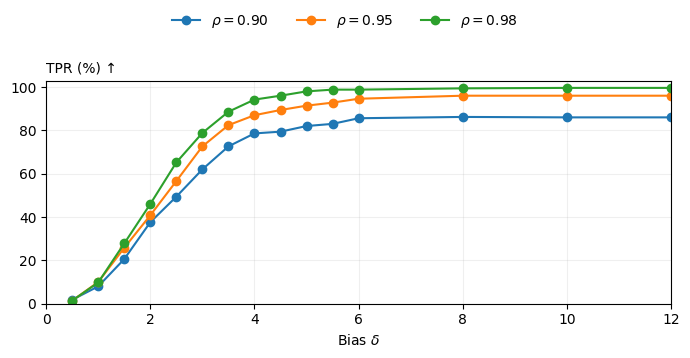

In [8]:
# Compare three head thresholds under the same temperature and detector.
fig, ax = plt.subplots(figsize=(7, 3.6))
for rho in (.90, .95, .98):
    subset = metrics[(metrics.method == "headmass") & metrics.gamma.eq(.5)
                     & metrics.rho.eq(rho)].sort_values("delta")
    ax.plot(subset.delta, 100 * subset.tpr, "o-", label=fr"$\rho={rho:.2f}$")
ax.set(xlabel=r"Bias $\delta$", xlim=(0, 12), ylim=(0, 103))
ax.set_xticks(range(0, 13, 2))
ax.set_title("TPR (%) ↑", loc="left", fontsize=10)
ax.grid(alpha=.2)
fig.legend(*ax.get_legend_handles_labels(), loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, .88))
plt.show()

Among the three examined head thresholds, ρ=0.98 reaches all three target detection rates within the shared bias grid. I use this threshold in the quality comparison below; this detection sweep alone does not establish an optimal threshold for quality.

### Comparison at target detection rates

For each target TPR (90%, 95%, 99%), I select the lowest-PPL configuration meeting the target, breaking ties by smaller bias. Actual TPRs need not be equal. The table includes Unwatermarked and Hard as references, matching the report's main comparison; complete quality–detection curves follow.

In [9]:
# Build the report comparison, including Unwatermarked and Hard references.
comparison = pd.concat([metrics.set_index("name").loc[["nw", "hard"]].reset_index().assign(target=float("nan")), targets], ignore_index=True)
comparison = comparison[["target", "method", "delta", "tpr", "ppl", "rouge1_fmeasure", "rouge2_fmeasure", "rougeL_fmeasure", "alignscore_nli_sp"]].copy()
comparison["method"] = comparison["method"].map({"none": "Unwatermarked", "hard_ow": "Hard", "kgw": "Soft", "headmass": "Stratified"})
comparison["target"] = comparison["target"].map(lambda value: "—" if pd.isna(value) else f"≥ {100*value:.0f}%")
comparison["tpr"] *= 100
comparison["ppl_change"] = comparison["ppl"] - nw["ppl"]
comparison.loc[comparison.method == "Unwatermarked", "ppl_change"] = float("nan")
comparison = comparison.rename(columns={"target": "Target TPR", "method": "Method", "delta": "δ", "tpr": "TPR (%) ↑", "ppl": "PPL ↓", "ppl_change": "PPL − baseline", "rouge1_fmeasure": "ROUGE-1 ↑", "rouge2_fmeasure": "ROUGE-2 ↑", "rougeL_fmeasure": "ROUGE-L ↑", "alignscore_nli_sp": "AlignScore ↑"})
comparison = comparison[["Target TPR", "Method", "δ", "TPR (%) ↑", "PPL ↓", "PPL − baseline", "ROUGE-1 ↑", "ROUGE-2 ↑", "ROUGE-L ↑", "AlignScore ↑"]]
display(comparison.style.hide(axis="index").format({
    "δ": "{:g}", "TPR (%) ↑": "{:.1f}", "PPL ↓": "{:.2f}", "PPL − baseline": "{:+.2f}",
    "ROUGE-1 ↑": "{:.2f}", "ROUGE-2 ↑": "{:.2f}", "ROUGE-L ↑": "{:.2f}", "AlignScore ↑": "{:.2f}"}, na_rep="—"))


Target TPR,Method,δ,TPR (%) ↑,PPL ↓,PPL − baseline,ROUGE-1 ↑,ROUGE-2 ↑,ROUGE-L ↑,AlignScore ↑
—,Unwatermarked,—,—,32.11,—,41.41,17.35,27.77,0.71
—,Hard,—,99.8,171.87,+139.76,26.63,5.21,14.86,0.25
≥ 90%,Soft,3,91.4,48.05,+15.93,37.68,13.14,23.34,0.54
≥ 90%,Stratified,4,94.2,37.79,+5.68,37.88,13.72,23.57,0.57
≥ 95%,Soft,3.5,96.8,53.82,+21.70,37.07,12.58,22.69,0.50
≥ 95%,Stratified,4.5,96.0,38.63,+6.52,37.19,12.77,22.74,0.54
≥ 99%,Soft,4.5,100.0,73.92,+41.81,33.04,9.36,19.59,0.39
≥ 99%,Stratified,12,99.6,42.04,+9.93,35.11,11.10,20.81,0.48


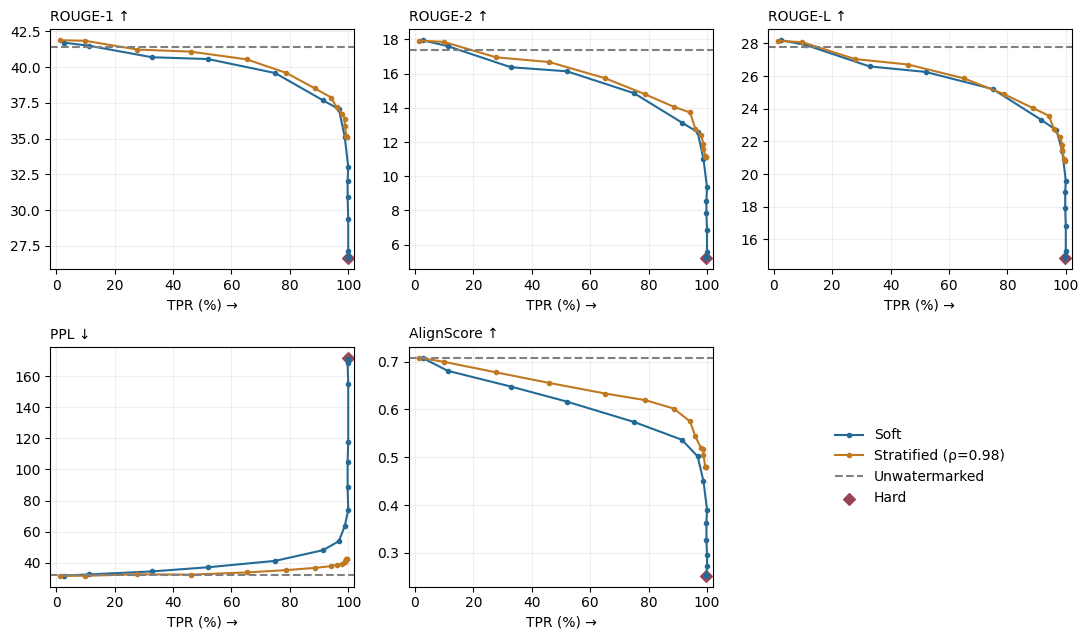

In [10]:
# Plot all measured bias settings, not only configurations selected for the table.
stratified = metrics[(metrics.method == "headmass") & metrics.gamma.eq(.5)
                     & metrics.rho.eq(.98)].sort_values("delta")
quality_metrics = [("rouge1_fmeasure", "ROUGE-1 ↑"), ("rouge2_fmeasure", "ROUGE-2 ↑"),
                   ("rougeL_fmeasure", "ROUGE-L ↑"), ("ppl", "PPL ↓"),
                   ("alignscore_nli_sp", "AlignScore ↑")]
fig, axes = plt.subplots(2, 3, figsize=(11, 6.5))
for ax, (metric, label) in zip(axes.flat, quality_metrics):
    for data, name, color in [(soft, "Soft", "#246a96"),
                              (stratified, "Stratified (ρ=0.98)", "#c07821")]:
        ax.plot(100 * data.tpr, data[metric], "o-", color=color, label=name, markersize=3)
    ax.axhline(nw[metric], color="gray", linestyle="--", label="Unwatermarked")
    ax.scatter([100 * hard.tpr], [hard[metric]], color="#994455", marker="D", label="Hard")
    ax.set(xlabel="TPR (%) →", xlim=(-2, 102))
    ax.set_title(label, loc="left", fontsize=10)
    ax.grid(alpha=.2)
axes.flat[-1].axis("off")
axes.flat[-1].legend(*axes.flat[0].get_legend_handles_labels(), loc="center", frameon=False)
fig.tight_layout()
plt.show()

**Result.** At all three target detection rates, Stratified has lower PPL and higher ROUGE and AlignScore than the corresponding Soft configuration selected by the same rule. The improvement reduces the quality loss relative to Soft; it does not restore unwatermarked quality. These results are descriptive comparisons on the fixed evaluation protocol, not claims of universal superiority.

## 6. Optional reproduction on a new GPU runtime

The cells above reconstruct the reported evidence without model inference. To generate new summaries, set `RUN_NEW=True` below. The default demo uses a small evaluation subset plus an independent calibration subset and runs the same generation, detection, ROUGE, PPL, and AlignScore pipeline. `main` runs the complete 200/500 split and 32 configurations; `full` adds sensitivity grids and is substantially more expensive.

Generation resumes at complete batch boundaries and evaluation stages verify source hashes. Save long runs to Google Drive. A small demo is a functional check, not a report-level estimate of 1% FPR.

In [11]:
RUN_NEW = False
MODE = "demo"       # "demo", "main", or "full"
N_DEMO = 16
N_CALIBRATION = 200
QUALITY = True
OUTPUT = "runs/online_demo"
if RUN_NEW:
    import torch
    if not torch.cuda.is_available(): raise RuntimeError("Select a GPU runtime")
    subprocess.run([sys.executable, "src/setup_assets.py"] + (["--quality"] if QUALITY else []), check=True)
    from workflow import run
    new_metrics = run(mode=MODE, n=N_DEMO, n_calibration=N_CALIBRATION, quality=QUALITY, output=OUTPUT)
    display(new_metrics)
    if QUALITY:
        from analysis import select_targets
        display(select_targets(new_metrics))

## 7. Inspect outputs and export

After a new run, the following cell shows the first evaluation article and reference, followed by the corresponding summaries from each method. This fixed selection avoids choosing a favorable example. `src/diagnostic.py` provides the optional same-prefix analysis described in the README. The cell also exports the run directory.

GPU and library changes can alter sampled text; no attack-robustness or human factual-accuracy claim follows from these examples.

In [12]:
if RUN_NEW:
    for directory in sorted(Path(OUTPUT).iterdir()):
        file = directory / "generations.jsonl"
        if file.exists() and directory.name != "unwatermarked_calibration":
            with file.open() as stream: row = json.loads(next(stream))
            if directory.name == "nw": print("SOURCE:", row["article"], "\nREFERENCE:", row["reference"])
            print(directory.name, "\nSummary:", row["summary"], "\n")
    import shutil
    archive = shutil.make_archive("watermark_run", "zip", OUTPUT)
    print("Exported:", archive)
    # In Colab: from google.colab import files; files.download(archive)

## References and verification

Original watermark: [Kirchenbauer et al., 2023](https://arxiv.org/abs/2301.10226). Model: [BART](https://aclanthology.org/2020.acl-main.703/). Metrics: [ROUGE](https://aclanthology.org/W04-1013/), [GPT-2](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf), [AlignScore](https://aclanthology.org/2023.acl-long.634/). Full references and dataset attribution appear in the report.

Local cached-model checks reproduced the sampled tokens and metrics for four methods on eight articles; independent calibration reproduced all 200 scores for five γ values. The saved-results notebook was executed locally. Fresh installation and model downloads in hosted Colab remain unverified. See `VERIFICATION.json` and the repository README for details.